# Build `specMask_GAS_narrow10_red`

This notebook creates a new GAS mask file from `specMask_GAS` using the same narrow10 rules as `20260317_create_specMask_GAS_narrow10.ipynb`, with a red-end exception:

1. Copy `sky` masks with `6800 < Lambda <= 8250` from `specMask_KIN_narrow10`.
2. For `Lambda > 8250`, use the original 5 Angstrom sky-mask setup from `specMask_KIN`; do not add the extra detected-peak masks from `specMask_KIN_narrow10`.
3. Keep target fitting regions unmasked for lines:
   - ArIII 7135.79
   - OII 7318.92, 7319.99, 7329.67, 7330.73
   - SIII 9068.60
4. Fitting regions use width 20 Angstrom and redshift range z in [-0.001, 0.01].
5. Any candidate sky mask that overlaps these fitting regions (even partially) is dropped.


In [1]:
from pathlib import Path

src_gas = Path('specMask_GAS')
src_kin_narrow = Path('specMask_KIN_narrow10')
src_kin_red_original = Path('specMask_KIN')
out_gas = Path('specMask_GAS_narrow10_red')

fit_lines = [7135.79, 7318.92, 7319.99, 7329.67, 7330.73, 9068.60]
z_min, z_max = -0.001, 0.01
fit_width = 20.0
fit_half = fit_width / 2.0
narrow_min_lambda = 6800.0
red_original_start = 8250.0


def parse_mask_file(path):
    headers = []
    entries = []
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line:
            headers.append(raw)
            continue
        if line.startswith('#'):
            headers.append(raw)
            continue

        parts = raw.split()
        if len(parts) < 3:
            headers.append(raw)
            continue

        lam_str, width_str = parts[0], parts[1]
        comment = ' '.join(parts[2:])
        try:
            lam = float(lam_str)
            width = float(width_str)
        except ValueError:
            headers.append(raw)
            continue

        entries.append({
            'lambda': lam,
            'width': width,
            'comment': comment,
            'lambda_str': lam_str,
            'width_str': width_str,
        })
    return headers, entries


def overlaps(a_lo, a_hi, b_lo, b_hi):
    return not (a_hi < b_lo or b_hi < a_lo)


def entry_key(entry):
    return (
        round(entry['lambda'], 9),
        round(entry['width'], 6),
        entry['comment'].strip().lower(),
    )


# Protected fitting windows after red/blueshift and +/- fit_half.
protected = []
for lam0 in fit_lines:
    lo = lam0 * (1.0 + z_min) - fit_half
    hi = lam0 * (1.0 + z_max) + fit_half
    protected.append((lo, hi, lam0))


def overlaps_protected(entry):
    sky_lo = entry['lambda'] - entry['width'] / 2.0
    sky_hi = entry['lambda'] + entry['width'] / 2.0
    return any(overlaps(sky_lo, sky_hi, p_lo, p_hi) for p_lo, p_hi, _ in protected)


# Add candidate sky masks while keeping fitting windows unmasked.
def add_candidate_sky_entries(entries, added, seen, label, min_exclusive, max_inclusive=None):
    dropped_here = []
    for entry in entries:
        if entry['comment'].strip().lower() != 'sky':
            continue
        if entry['lambda'] <= min_exclusive:
            continue
        if max_inclusive is not None and entry['lambda'] > max_inclusive:
            continue

        if overlaps_protected(entry):
            dropped_here.append((label, entry))
            continue

        key = entry_key(entry)
        if key not in seen:
            added.append(entry)
            seen.add(key)
    return dropped_here


gas_headers, gas_entries = parse_mask_file(src_gas)
# Header note is copied from the original file; correct module label for this output.
gas_headers = [h.replace('SFH module', 'GAS module') for h in gas_headers]
_, kin_narrow_entries = parse_mask_file(src_kin_narrow)
_, kin_red_original_entries = parse_mask_file(src_kin_red_original)

# Existing entries signature to avoid duplicates when appending.
seen = {entry_key(entry) for entry in gas_entries}

added_narrow = []
added_red_original = []
dropped = []

dropped.extend(add_candidate_sky_entries(
    kin_narrow_entries,
    added_narrow,
    seen,
    label=f'{src_kin_narrow} ({narrow_min_lambda:.0f} < Lambda <= {red_original_start:.0f})',
    min_exclusive=narrow_min_lambda,
    max_inclusive=red_original_start,
))
dropped.extend(add_candidate_sky_entries(
    kin_red_original_entries,
    added_red_original,
    seen,
    label=f'{src_kin_red_original} (Lambda > {red_original_start:.0f})',
    min_exclusive=red_original_start,
))

ignored_narrow_red = [
    entry for entry in kin_narrow_entries
    if entry['comment'].strip().lower() == 'sky' and entry['lambda'] > red_original_start
]

all_entries = gas_entries + added_narrow + added_red_original

with out_gas.open('w') as f:
    for h in gas_headers:
        f.write(h + '\n')

    for entry in all_entries:
        f.write(f"{entry['lambda']:10.6f}    {entry['width']:6.2f}    {entry['comment']}\n")
print(f'Wrote: {out_gas}')
print(f'Base GAS entries: {len(gas_entries)}')
print(f'Added narrow sky entries ({narrow_min_lambda:.0f} < Lambda <= {red_original_start:.0f}): {len(added_narrow)}')
print(f'Added original red sky entries (Lambda > {red_original_start:.0f}): {len(added_red_original)}')
print(f'Ignored narrow10 red sky entries (Lambda > {red_original_start:.0f}): {len(ignored_narrow_red)}')
print(f'Dropped due to overlap with fitting windows: {len(dropped)}')

if dropped:
    sample = [(label, round(entry['lambda'], 3)) for label, entry in dropped[:15]]
    print('Sample dropped source/lambda:', sample)


Wrote: specMask_GAS_narrow10_red
Base GAS entries: 7
Added narrow sky entries (6800 < Lambda <= 8250): 104
Added original red sky entries (Lambda > 8250): 71
Ignored narrow10 red sky entries (Lambda > 8250): 87
Dropped due to overlap with fitting windows: 17
Sample dropped source/lambda: [('specMask_KIN_narrow10 (6800 < Lambda <= 8250)', 7303.676), ('specMask_KIN_narrow10 (6800 < Lambda <= 8250)', 7303.751), ('specMask_KIN_narrow10 (6800 < Lambda <= 8250)', 7316.234), ('specMask_KIN_narrow10 (6800 < Lambda <= 8250)', 7316.306), ('specMask_KIN_narrow10 (6800 < Lambda <= 8250)', 7329.123), ('specMask_KIN_narrow10 (6800 < Lambda <= 8250)', 7329.175), ('specMask_KIN_narrow10 (6800 < Lambda <= 8250)', 7340.807), ('specMask_KIN_narrow10 (6800 < Lambda <= 8250)', 7340.951), ('specMask_KIN_narrow10 (6800 < Lambda <= 8250)', 7358.666), ('specMask_KIN_narrow10 (6800 < Lambda <= 8250)', 7358.673), ('specMask_KIN_narrow10 (6800 < Lambda <= 8250)', 7369.249), ('specMask_KIN_narrow10 (6800 < Lambda 

## Plot sky spectrum with masking overlays

Gray spans are sky-mask regions from `specMask_GAS_narrow10_red`.
For `Lambda > 8250 Angstrom`, these are the original red sky-line regions from `specMask_KIN` with their original 5 Angstrom widths; extra detected-peak masks from `specMask_KIN_narrow10` are not added in this red range.
Green spans are protected fitting regions only for `Lambda > 6800 Angstrom` (20 Angstrom width, redshift range `z in [-0.001, 0.01]`) for:
- ArIII 7135.79
- OII 7318.92, 7319.99, 7329.67, 7330.73
- SIII 9068.60


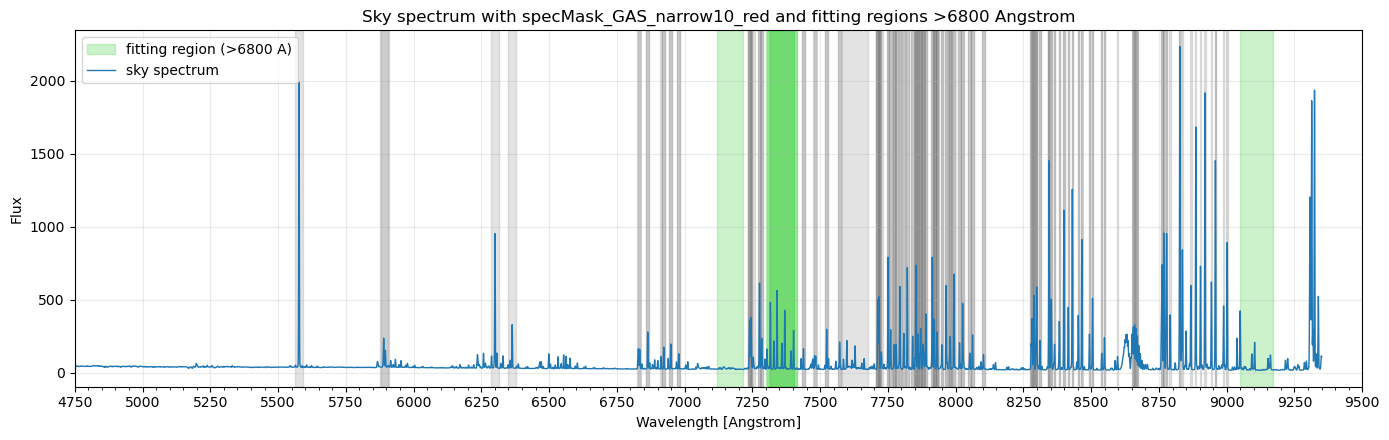

FITS file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/SKY_SPECTRUM_2023-01-18T07_13_15_0001.fits
Mask file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_GAS_narrow10_red
Red original-mask threshold: Lambda > 8250 Angstrom
Sky-mask spans shown: 180
Fitting regions shown (Lambda > 6800 Angstrom): 6


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.io import fits

fits_path = Path.cwd() / 'SKY_SPECTRUM_2023-01-18T07_13_15_0001.fits'
mask_path = Path.cwd() / 'specMask_GAS_narrow10_red'

fit_lines = [7135.79, 7318.92, 7319.99, 7329.67, 7330.73, 9068.60]
fit_min_lambda = 6800.0
red_original_start = 8250.0
z_min, z_max = -0.001, 0.01
fit_width = 20.0
fit_half = fit_width / 2.0


def load_sky_masks(path):
    masks = []
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line or line.startswith('#'):
            continue
        parts = raw.split()
        if len(parts) < 3:
            continue
        try:
            lam = float(parts[0])
            width = float(parts[1])
        except ValueError:
            continue
        if parts[2].strip().lower() == 'sky':
            half = width / 2.0
            masks.append((lam - half, lam + half, lam, width))
    return masks


def load_spectrum(path):
    with fits.open(path) as hdul:
        data_hdu_idx = None
        for i, hdu in enumerate(hdul):
            if getattr(hdu, 'data', None) is not None:
                data_hdu_idx = i
                break
        if data_hdu_idx is None:
            raise ValueError('No data HDU found in FITS file.')

        data = hdul[data_hdu_idx].data

    if hasattr(data, 'names') and data.names is not None:
        wave_col = None
        flux_col = None
        for name in data.names:
            low = name.lower()
            if wave_col is None and low in ('lambda', 'wave', 'wavelength', 'lam'):
                wave_col = name
            if flux_col is None and low in ('data', 'flux', 'spec', 'spectrum'):
                flux_col = name
        if wave_col is None:
            wave_col = data.names[0]
        if flux_col is None:
            flux_col = data.names[1] if len(data.names) >= 2 else data.names[0]

        wave = np.asarray(data[wave_col], dtype=float)
        flux = np.asarray(data[flux_col], dtype=float)
    else:
        arr = np.asarray(data, dtype=float)
        if arr.ndim != 1:
            raise ValueError('Expected 1D spectrum or table with wavelength/flux columns.')
        wave = np.arange(arr.size, dtype=float)
        flux = arr

    finite = np.isfinite(wave) & np.isfinite(flux)
    return wave[finite], flux[finite]


def add_sky_spans(ax, masks, wave):
    wmin, wmax = np.nanmin(wave), np.nanmax(wave)
    n = 0
    for left, right, _, _ in masks:
        if right < wmin or left > wmax:
            continue
        ax.axvspan(left, right, color='gray', alpha=0.22, zorder=0)
        n += 1
    return n


def add_fit_spans(ax, lines, min_lambda, z0, z1, half_width):
    spans = []
    for lam0 in lines:
        if lam0 <= min_lambda:
            continue
        left = lam0 * (1.0 + z0) - half_width
        right = lam0 * (1.0 + z1) + half_width
        spans.append((left, right, lam0))
    for i, (left, right, _) in enumerate(spans):
        ax.axvspan(left, right, color='limegreen', alpha=0.25, zorder=1,
                   label='fitting region (>6800 A)' if i == 0 else None)
    return spans


def configure_ticks(ax, wmin, wmax):
    span = wmax - wmin
    if span <= 800:
        major, minor = 50.0, 10.0
    elif span <= 2000:
        major, minor = 100.0, 20.0
    else:
        major, minor = 250.0, 50.0
    first = np.floor(wmin / major) * major
    last = np.ceil(wmax / major) * major
    ax.set_xticks(np.arange(first, last + major, major))
    ax.xaxis.set_minor_locator(MultipleLocator(minor))


if not fits_path.exists():
    raise FileNotFoundError(f'FITS file not found: {fits_path}')
if not mask_path.exists():
    raise FileNotFoundError(f'Mask file not found: {mask_path}')

sky_masks = load_sky_masks(mask_path)
wave, flux = load_spectrum(fits_path)

fig, ax = plt.subplots(figsize=(14, 4.5))
shown_sky = add_sky_spans(ax, sky_masks, wave)
fit_spans = add_fit_spans(ax, fit_lines, fit_min_lambda, z_min, z_max, fit_half)

ax.plot(wave, flux, lw=1.0, color='tab:blue', label='sky spectrum', zorder=2)
ax.set_xlim(np.nanmin(wave), np.nanmax(wave))
ax.set_xlabel('Wavelength [Angstrom]')
ax.set_ylabel('Flux')
ax.set_title('Sky spectrum with specMask_GAS_narrow10_red and fitting regions >6800 Angstrom')
configure_ticks(ax, np.nanmin(wave), np.nanmax(wave))
ax.grid(alpha=0.25)
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

print(f'FITS file: {fits_path}')
print(f'Mask file: {mask_path}')
print(f'Red original-mask threshold: Lambda > {red_original_start:.0f} Angstrom')
print(f'Sky-mask spans shown: {shown_sky}')
print(f'Fitting regions shown (Lambda > {fit_min_lambda:.0f} Angstrom): {len(fit_spans)}')
